# Motif curation

Review the 70 clustered motifs from ChromBPNet modisco → gimme cluster → TomTom.
Filter by annotation quality, check for redundancy, classify by biological function.

Reference: Nair et al. Section 2.8.1 — they curated 30 non-redundant predictive motifs
from their modisco results, excluding poor TomTom matches and resolving ambiguities.

In [1]:
import os
import numpy as np
import pandas as pd
import logomaker as lm
from tangermeme.io import read_meme

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {'A': '#109648', 'C': '#255C99', 'G': '#F7B32B', 'T': '#D62839'}

In [2]:
dataset = 'sc-islet-differentiation_10X-Multiome'
base_dir = f'/cellar/users/aklie/data/datasets/{dataset}'
results_dir = f'{base_dir}/results/3_single_task_models'
path_motif_file = f'{results_dir}/motifs/gimme_cluster/meme/combined.meme'
path_motif_annotation = f'{results_dir}/motifs/gimme_cluster/tfs_initial.txt'
path_out = f'{results_dir}/motifs/gimme_cluster/summary'
os.makedirs(path_out, exist_ok=True)

# Load
motif_dict = read_meme(path_motif_file)
motifs_df = pd.read_csv(path_motif_annotation, sep='\t', header=None,
                         names=['cluster_name', 'annotation', 'evalue'])

# Derived columns
motifs_df['tf_name'] = motifs_df['annotation'].apply(lambda x: x.split('_')[0].split('.')[0])
motifs_df['source'] = motifs_df['cluster_name'].apply(lambda x: 'cell_type_specific' if '.counts.' in x else 'averaged')
motifs_df['log_evalue'] = np.log10(motifs_df['evalue'].clip(lower=1e-30))

# E-value quality tier
motifs_df['quality'] = pd.cut(motifs_df['evalue'],
    bins=[0, 1e-10, 1e-5, 0.01, 0.1, 1, 100],
    labels=['excellent', 'strong', 'moderate', 'weak', 'poor', 'no_match'])

print(f'{len(motifs_df)} motifs loaded')
motifs_df.head()

70 motifs loaded


,cluster_name,annotation,evalue,tf_name,source,log_evalue,quality
0,Average_131,ZN143_MOUSE.H11MO.0.A,7.288700e-24,ZN143,averaged,-23.137350,excellent
1,Average_168,REST_MA0138.2,2.329340e-22,REST,averaged,-21.632767,excellent
2,Average_664,CTCF_MA0139.1,3.235860e-20,CTCF,averaged,-19.490010,excellent
3,Average_655,SOX9_HUMAN.H11MO.0.B,1.066940e-12,SOX9,averaged,-11.971860,excellent
4,Average_640,HNF4G_MA0484.1,2.638560e-12,HNF4G,averaged,-11.578633,excellent


# Overview

In [3]:
print('=== Quality tiers ===')
print(motifs_df['quality'].value_counts().sort_index())
print(f'\n=== Source ===')
print(motifs_df['source'].value_counts())

# Duplicate TF families
dupes = motifs_df['tf_name'].value_counts()
dupes = dupes[dupes > 1]
print(f'\n=== {len(dupes)} TF families with multiple motifs ===')
for tf in dupes.index:
    rows = motifs_df[motifs_df['tf_name'] == tf][['cluster_name', 'annotation', 'evalue', 'quality']]
    print(f'\n{tf}:')
    for _, r in rows.iterrows():
        print(f'  {r["cluster_name"]:45s} {r["annotation"]:35s} e={r["evalue"]:.2e} [{r["quality"]}]')

=== Quality tiers ===
excellent     6
strong       20
moderate     28
weak         12
poor          2
no_match      2
Name: quality, dtype: int64

=== Source ===
averaged              50
cell_type_specific    20
Name: source, dtype: int64

=== 8 TF families with multiple motifs ===

CTCF:
  Average_664                                   CTCF_MA0139.1                       e=3.24e-20 [excellent]
  PFG2.counts.pattern_21.pfm                    CTCF_MA0139.1                       e=8.73e-03 [moderate]

PAX6:
  early_SC_alpha.counts.pattern_33.pfm          PAX6_PAX_1                          e=9.93e-05 [moderate]
  Average_642                                   PAX6_HUMAN.H11MO.0.C                e=5.19e-02 [weak]

REST:
  Average_168                                   REST_MA0138.2                       e=2.33e-22 [excellent]
  Average_636                                   REST_HUMAN.H11MO.0.A                e=7.07e-04 [moderate]

CTCFL:
  PP2.counts.pattern_39.pfm                     CTCFL_

# Full motif catalog with logos

Logo + annotation + e-value + quality tier for all 70 motifs, ordered by e-value.

Saved full catalog (70 motifs) with quality indicators
Green=excellent, Blue=strong, Orange=moderate, Red=weak, Gray=poor, Yellow=no_match


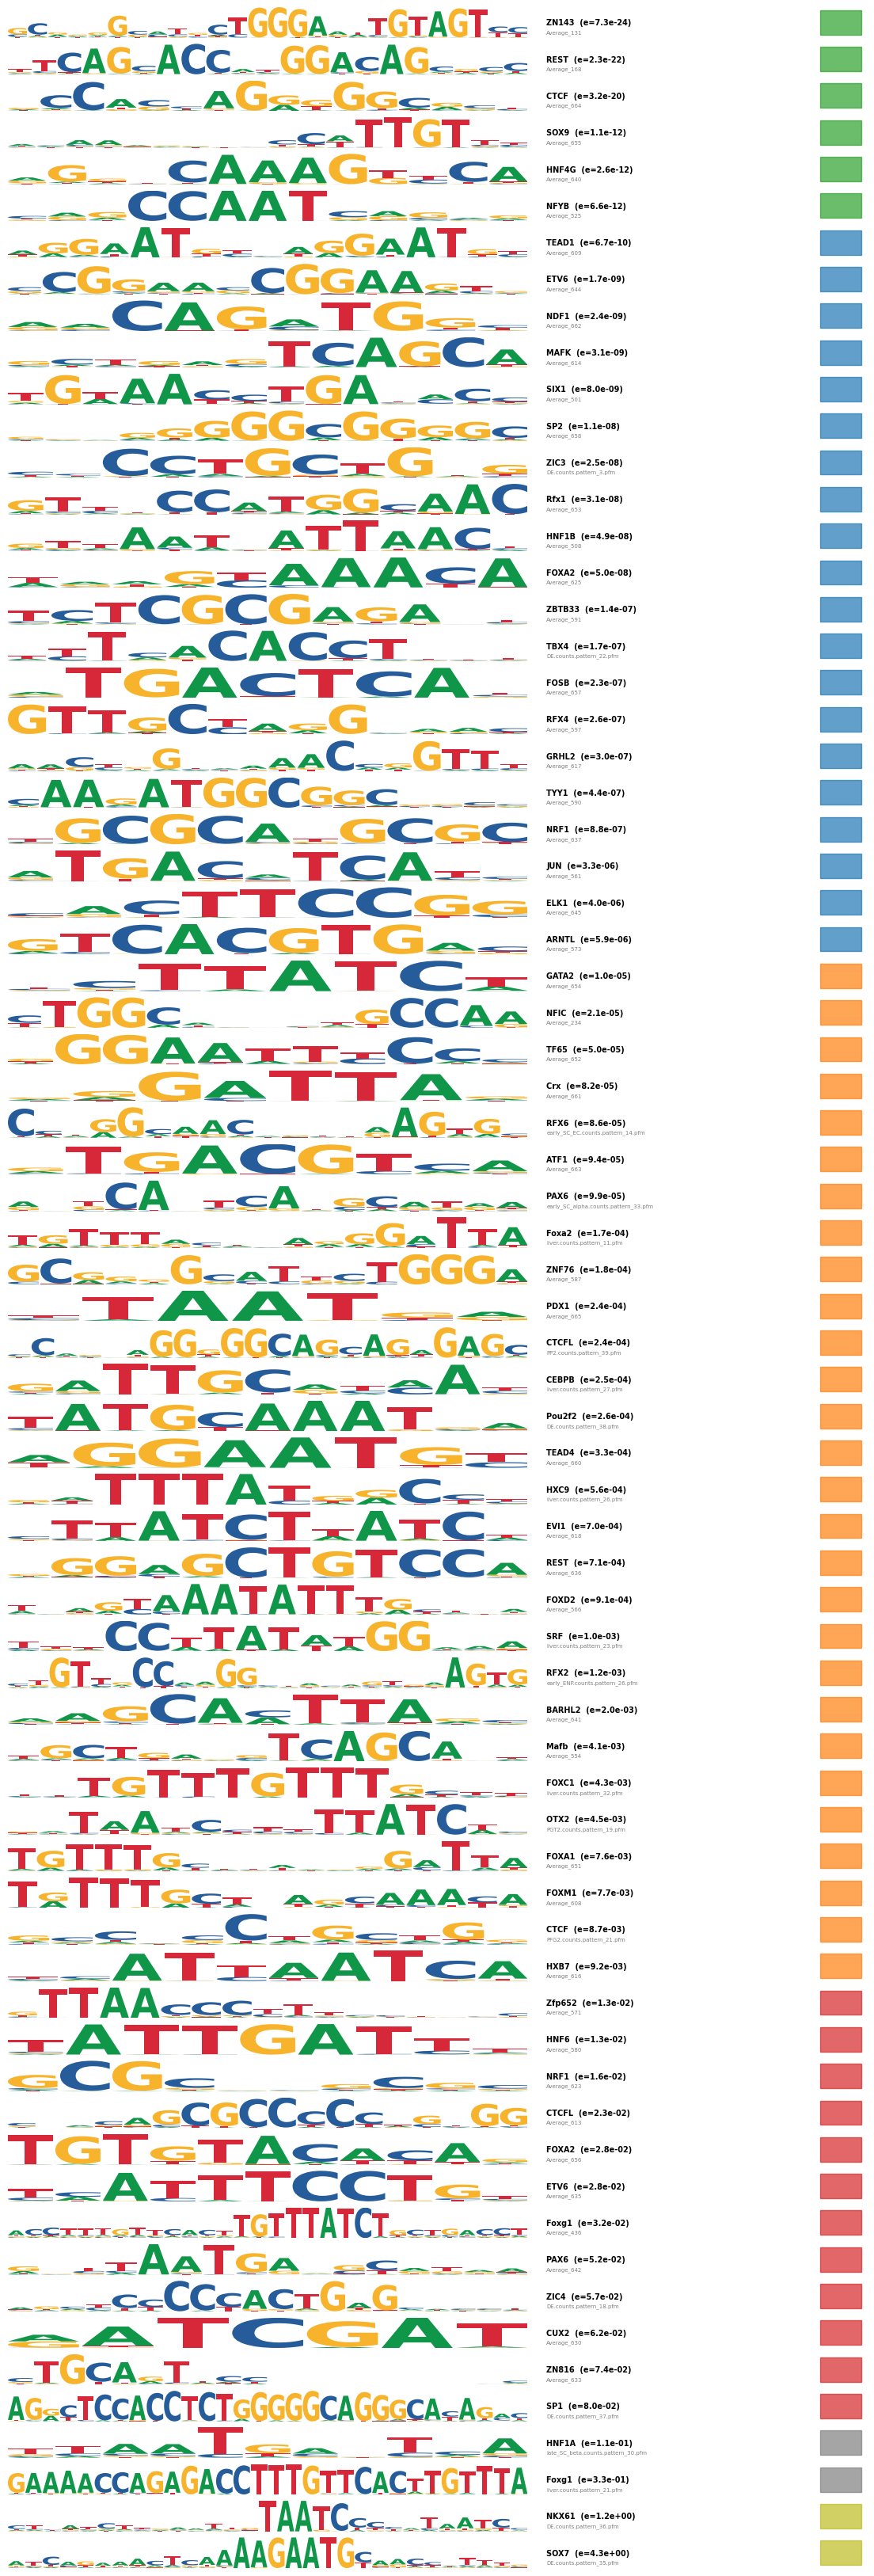

In [4]:
# Sort by e-value
df_sorted = motifs_df.sort_values('evalue').reset_index(drop=True)
n = len(df_sorted)

fig = plt.figure(figsize=(14, n * 0.6), dpi=100)
gs = gridspec.GridSpec(n, 3, width_ratios=[3, 1.5, 0.3], wspace=0.05)

for i, row in df_sorted.iterrows():
    motif_name = row['cluster_name']
    annotation = row['tf_name']
    evalue = row['evalue']
    quality = row['quality']
    
    # Quality color
    qcolor = {'excellent': '#2ca02c', 'strong': '#1f77b4', 'moderate': '#ff7f0e',
              'weak': '#d62728', 'poor': '#7f7f7f', 'no_match': '#bcbd22'}[quality]
    
    # Logo
    ax_logo = fig.add_subplot(gs[i, 0])
    ppm = motif_dict[motif_name].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability', to_type='information',
    )
    lm.Logo(lm_df, ax=ax_logo, color_scheme=LOGO_COLORS, fade_below=0.1)
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])
    for spine in ax_logo.spines.values():
        spine.set_visible(False)
    
    # Annotation label
    ax_label = fig.add_subplot(gs[i, 1])
    ax_label.text(0.02, 0.5, f'{annotation}  (e={evalue:.1e})',
                  ha='left', va='center', fontsize=7, fontweight='bold')
    ax_label.text(0.02, 0.1, motif_name, ha='left', va='bottom', fontsize=5, color='gray')
    ax_label.set_xlim(0, 1)
    ax_label.set_xticks([])
    ax_label.set_yticks([])
    for spine in ax_label.spines.values():
        spine.set_visible(False)
    
    # Quality indicator
    ax_q = fig.add_subplot(gs[i, 2])
    ax_q.add_patch(plt.Rectangle((0.1, 0.1), 0.8, 0.8, color=qcolor, alpha=0.7))
    ax_q.set_xlim(0, 1)
    ax_q.set_ylim(0, 1)
    ax_q.set_xticks([])
    ax_q.set_yticks([])
    for spine in ax_q.spines.values():
        spine.set_visible(False)

plt.savefig(f'{path_out}/motif_catalog_full.pdf', dpi=150, bbox_inches='tight')
print(f'Saved full catalog ({n} motifs) with quality indicators')
print('Green=excellent, Blue=strong, Orange=moderate, Red=weak, Gray=poor, Yellow=no_match')
plt.show()

# Classify motifs by biological function

Group motifs into functional categories relevant to islet differentiation.

In [5]:
# Known TF families relevant to islet differentiation (from Liu et al. KO village paper)
islet_tfs = {
    'endocrine_master': ['PDX1', 'NKX2', 'NKX6', 'PAX6', 'NEUROD', 'RFX6', 'RFX2', 'RFX4', 'ISL1', 'MAFA', 'MAFB'],
    'early_patterning': ['SOX', 'FOXA', 'HNF1', 'HNF4', 'HNF6', 'GATA', 'CDX2', 'OTX2'],
    'signaling_effectors': ['TEAD', 'SMAD', 'JUN', 'FOS', 'ATF', 'CREB', 'ETS', 'ETV', 'ELK'],
    'structural': ['CTCF', 'CTCFL', 'REST', 'ZN143', 'NRF1', 'NFY', 'SP1', 'SP2'],
    'cell_cycle': ['FOXM1', 'E2F'],
    'other_developmental': ['TBX', 'SIX', 'BARHL', 'CUX', 'ZIC', 'GRHL', 'ARNTL', 'EVI1'],
}

def classify_motif(tf_name):
    tf_upper = tf_name.upper()
    for category, tfs in islet_tfs.items():
        for tf in tfs:
            if tf.upper() in tf_upper:
                return category
    return 'unclassified'

motifs_df['category'] = motifs_df['tf_name'].apply(classify_motif)

print('=== Motif categories ===')
for cat in list(islet_tfs.keys()) + ['unclassified']:
    rows = motifs_df[motifs_df['category'] == cat]
    if len(rows) > 0:
        print(f'\n{cat} ({len(rows)}):')
        for _, r in rows.iterrows():
            print(f'  {r["tf_name"]:15s} {r["cluster_name"]:45s} e={r["evalue"]:.2e} [{r["quality"]}]')

=== Motif categories ===

endocrine_master (8):
  RFX4            Average_597                                   e=2.64e-07 [strong]
  RFX6            early_SC_EC.counts.pattern_14.pfm             e=8.63e-05 [moderate]
  PAX6            early_SC_alpha.counts.pattern_33.pfm          e=9.93e-05 [moderate]
  PDX1            Average_665                                   e=2.36e-04 [moderate]
  RFX2            early_ENP.counts.pattern_26.pfm               e=1.20e-03 [moderate]
  Mafb            Average_554                                   e=4.15e-03 [moderate]
  PAX6            Average_642                                   e=5.19e-02 [weak]
  NKX61           DE.counts.pattern_36.pfm                      e=1.16e+00 [no_match]

early_patterning (12):
  SOX9            Average_655                                   e=1.07e-12 [excellent]
  HNF4G           Average_640                                   e=2.64e-12 [excellent]
  HNF1B           Average_508                                   e=4.91e-

# Recommended filtering

Based on Nair et al.: exclude motifs with poor TomTom matches, resolve redundancy.

In [6]:
# Flag motifs for potential issues
motifs_df['flag_poor_match'] = motifs_df['evalue'] > 0.1
motifs_df['flag_redundant'] = motifs_df.duplicated(subset='tf_name', keep='first') & (motifs_df['tf_name'].map(motifs_df['tf_name'].value_counts()) > 1)

# For redundant pairs, keep the one with better e-value
redundant = motifs_df[motifs_df['flag_redundant']]
print(f'=== Flagged for removal ===')
print(f'Poor TomTom match (e > 0.1): {motifs_df["flag_poor_match"].sum()}')
print(f'Redundant (worse of duplicate pair): {motifs_df["flag_redundant"].sum()}')

# Curated set
curated = motifs_df[~motifs_df['flag_poor_match'] & ~motifs_df['flag_redundant']].copy()
print(f'\nCurated set: {len(curated)} motifs (from {len(motifs_df)} original)')

# Save
motifs_df.to_csv(f'{path_out}/motif_annotations_full.csv', index=False)
curated.to_csv(f'{path_out}/motif_annotations_curated.csv', index=False)

print(f'\n=== Curated motif categories ===')
print(curated['category'].value_counts())

=== Flagged for removal ===
Poor TomTom match (e > 0.1): 4
Redundant (worse of duplicate pair): 8

Curated set: 59 motifs (from 70 original)

=== Curated motif categories ===
unclassified           19
early_patterning        9
other_developmental     9
structural              8
signaling_effectors     7
endocrine_master        6
cell_cycle              1
Name: category, dtype: int64


In [7]:
# Show what was flagged
flagged = motifs_df[motifs_df['flag_poor_match'] | motifs_df['flag_redundant']]
print(f'=== Flagged motifs ({len(flagged)}) ===')
for _, r in flagged.iterrows():
    reasons = []
    if r['flag_poor_match']: reasons.append('poor_match')
    if r['flag_redundant']: reasons.append('redundant')
    print(f'  {r["tf_name"]:15s} {r["cluster_name"]:45s} e={r["evalue"]:.2e} [{"|".join(reasons)}]')

=== Flagged motifs (11) ===
  REST            Average_636                                   e=7.07e-04 [redundant]
  CTCF            PFG2.counts.pattern_21.pfm                    e=8.73e-03 [redundant]
  NRF1            Average_623                                   e=1.60e-02 [redundant]
  CTCFL           Average_613                                   e=2.33e-02 [redundant]
  FOXA2           Average_656                                   e=2.79e-02 [redundant]
  ETV6            Average_635                                   e=2.82e-02 [redundant]
  PAX6            Average_642                                   e=5.19e-02 [redundant]
  HNF1A           late_SC_beta.counts.pattern_30.pfm            e=1.06e-01 [poor_match]
  Foxg1           liver.counts.pattern_21.pfm                   e=3.32e-01 [poor_match|redundant]
  NKX61           DE.counts.pattern_36.pfm                      e=1.16e+00 [poor_match]
  SOX7            DE.counts.pattern_35.pfm                      e=4.30e+00 [poor_match]


# DONE!

## Next steps
- Build pseudobulk RNA expression matrix from CellRanger outputs (see Muto `5_build_rna_anndata.py`)
- Overlay TF expression on motif hit importance heatmap
- Use curated motif set for downstream analyses (peak set clustering, syntax analysis)